In [9]:
"""
Etapa 3 — Modelagem dos bairros do Rio
K-Means clustering para identificar tipologia de bairros 
em relação à oferta e demanda de transporte público.
"""

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [10]:
# Configuração visual
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150
sns.set_style("whitegrid")

# Carregar dados
df = gpd.read_parquet("../data/processed/bairros_dti.parquet")
df = df.set_crs("EPSG:4326")

# Adicionar paradas_por_km2 (não está no parquet)
df["paradas_por_km2"] = df["n_paradas"] / df["area_km2"]

# Tratar NaN no headway (apenas GRUMARI e GERICINÓ)
df["headway_medio_min"] = df["headway_medio_min"].fillna(df["headway_medio_min"].median())

print(f"Bairros carregados: {len(df)}")
print(f"Colunas disponíveis: {df.columns.tolist()}")
print(f"\nDTI - estatísticas:")
print(df["DTI"].describe())

Bairros carregados: 164
Colunas disponíveis: ['bairro', 'codbairro', 'regiao_adm', 'codra', 'area_km2', 'populacao', 'domicilios', 'densidade_hab_km2', 'ips', 'n_paradas', 'n_linhas', 'headway_medio_min', 'cobertura_400m', 'geometry', 'DTI', 'paradas_por_km2']

DTI - estatísticas:
count    164.000000
mean      48.869670
std        8.387979
min       26.194849
25%       45.200964
50%       48.585529
75%       52.936400
max       79.754472
Name: DTI, dtype: float64


In [11]:
features = [
    "densidade_hab_km2",   # Demanda
    "ips",                  # Demanda (vulnerabilidade)
    "n_paradas",            # Oferta
    "paradas_por_km2",      # Oferta (densidade)
    "n_linhas",             # Oferta (diversidade)
    "cobertura_400m",       # Oferta (distribuição espacial)
    "headway_medio_min",    # Oferta (frequência)
]

X = df[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Matriz preparada: {X_scaled.shape}")
print(f"Features usadas: {features}")

Matriz preparada: (164, 7)
Features usadas: ['densidade_hab_km2', 'ips', 'n_paradas', 'paradas_por_km2', 'n_linhas', 'cobertura_400m', 'headway_medio_min']


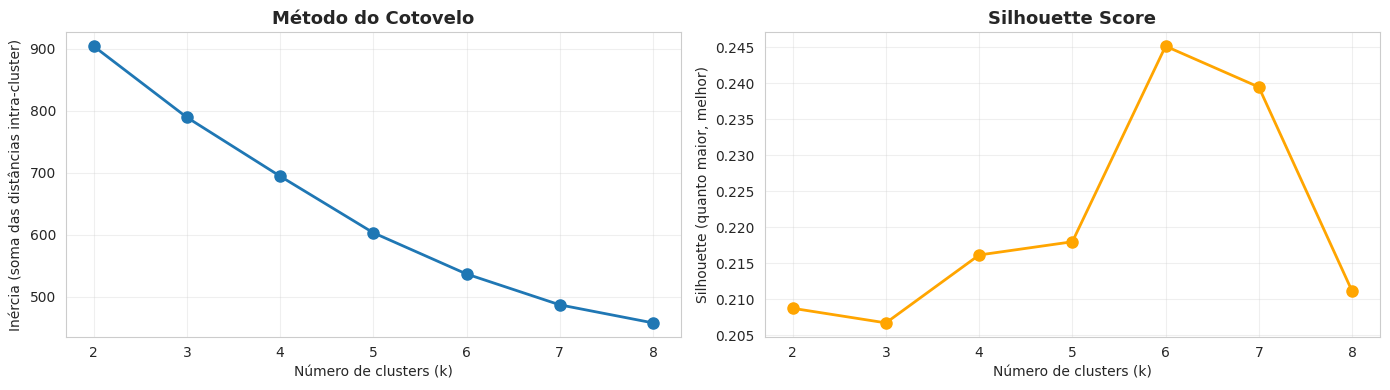


Valores de Silhouette por k:
  k=2: 0.209
  k=3: 0.207
  k=4: 0.216
  k=5: 0.218
  k=6: 0.245
  k=7: 0.239
  k=8: 0.211


In [12]:
ks = range(2, 9)
inertias = []
silhouettes = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

# Plot dos critérios
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(ks, inertias, 'o-', linewidth=2, markersize=8)
axes[0].set_title('Método do Cotovelo', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Inércia (soma das distâncias intra-cluster)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(ks, silhouettes, 'o-', color='orange', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Silhouette (quanto maior, melhor)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nValores de Silhouette por k:")
for k, s in zip(ks, silhouettes):
    print(f"  k={k}: {s:.3f}")

In [13]:
K_ESCOLHIDO = 6

km_final = KMeans(n_clusters=K_ESCOLHIDO, random_state=42, n_init=10)
df["cluster"] = km_final.fit_predict(X_scaled)

# Caracterização: média de cada feature por cluster
print(f"\n{'='*70}")
print(f"PERFIS DOS {K_ESCOLHIDO} CLUSTERS")
print(f"{'='*70}\n")

perfis = df.groupby("cluster").agg({
    "DTI": "mean",
    "densidade_hab_km2": "mean",
    "ips": "mean",
    "n_paradas": "mean",
    "cobertura_400m": "mean",
    "headway_medio_min": "mean",
    "n_linhas": "mean",
    "bairro": "count",
}).round(2)
perfis = perfis.rename(columns={"bairro": "n_bairros"})
print(perfis)

# Listar bairros típicos de cada cluster (top 5 por DTI dentro do cluster)
print(f"\n{'='*70}")
print(f"BAIRROS TÍPICOS POR CLUSTER")
print(f"{'='*70}\n")

for c in range(K_ESCOLHIDO):
    bairros_cluster = df[df["cluster"] == c].sort_values("DTI", ascending=False)
    n = len(bairros_cluster)
    dti_medio = bairros_cluster["DTI"].mean()
    
    print(f"\n--- Cluster {c} ({n} bairros, DTI médio: {dti_medio:.1f}) ---")
    print(bairros_cluster[["bairro", "regiao_adm", "DTI", "ips", "cobertura_400m"]].head(5).to_string(index=False))


PERFIS DOS 6 CLUSTERS

           DTI  densidade_hab_km2    ips  n_paradas  cobertura_400m  \
cluster                                                               
0        48.64           12915.22  60.42      33.27            0.92   
1        37.19           13426.15  84.21      39.35            0.80   
2        52.12            4612.75  61.91      38.26            0.49   
3        59.00           12443.58  51.31      42.89            0.79   
4        45.09           11722.72  55.55      68.95            0.92   
5        50.98            3632.65  59.66     283.00            0.40   

         headway_medio_min  n_linhas  n_bairros  
cluster                                          
0                    23.41     35.82         62  
1                    21.79     43.60         20  
2                    23.84     33.63         35  
3                    31.93     39.47         19  
4                    25.47    141.55         20  
5                    23.80     87.62          8  

BAIRRO

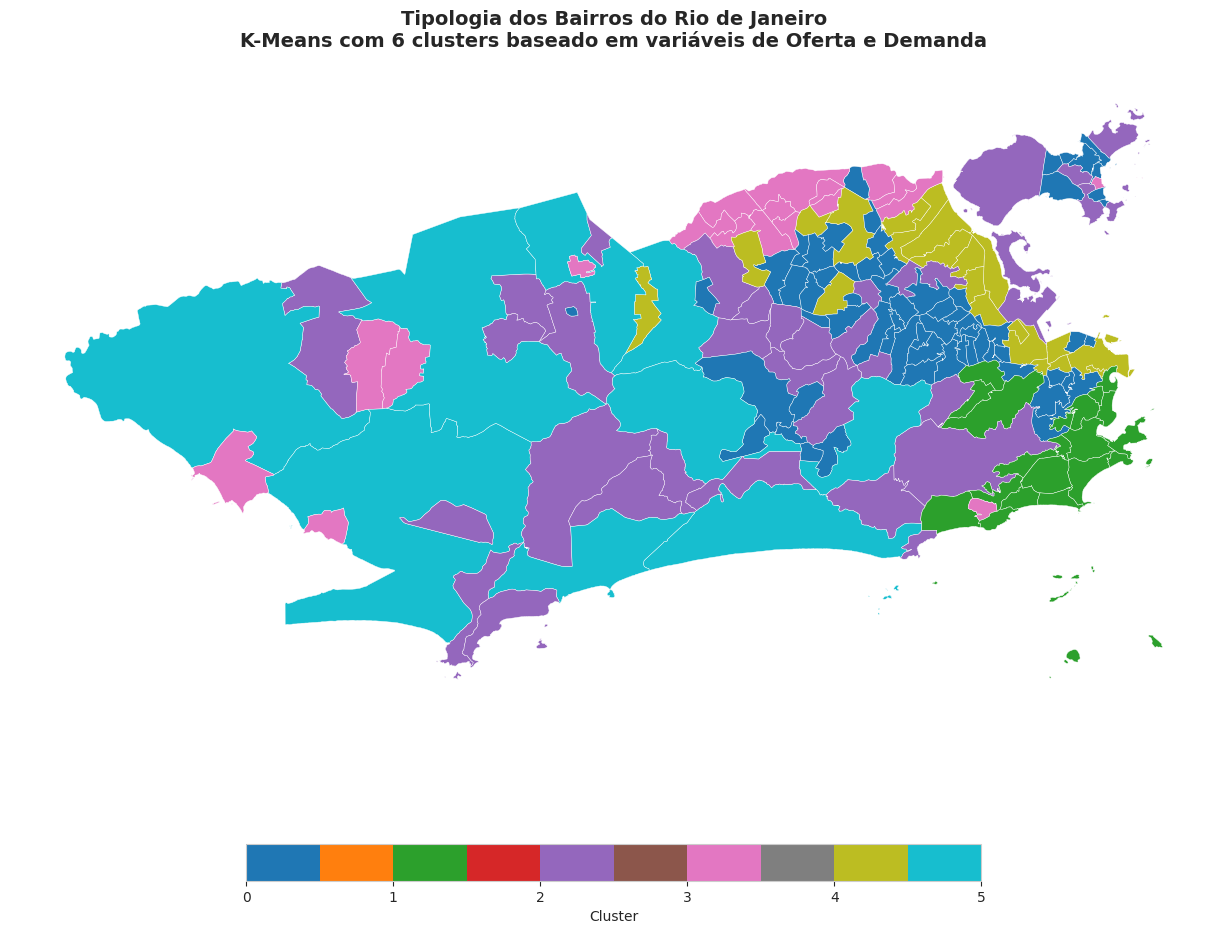

In [16]:
fig, ax = plt.subplots(figsize=(15, 10))

df.plot(
    column="cluster",
    cmap="tab10",
    legend=True,
    edgecolor="white",
    linewidth=0.3,
    ax=ax,
    legend_kwds={"label": "Cluster", "orientation": "horizontal", "shrink": 0.5}
)

ax.set_title(
    f"Tipologia dos Bairros do Rio de Janeiro\n"
    f"K-Means com {K_ESCOLHIDO} clusters baseado em variáveis de Oferta e Demanda",
    fontsize=14, fontweight='bold', pad=20
)
ax.set_axis_off()

plt.tight_layout()
plt.show()

df.to_parquet("../data/processed/bairros_dti_clusters.parquet")

In [17]:
# Listar bairros típicos de cada cluster com nomes definitivos
print(f"\n{'='*70}")
print(f"BAIRROS TÍPICOS POR CLUSTER (top 5 por DTI)")
print(f"{'='*70}")

for c in range(6):
    bairros_cluster = df[df["cluster"] == c].sort_values("DTI", ascending=False)
    n = len(bairros_cluster)
    dti_medio = bairros_cluster["DTI"].mean()
    
    print(f"\n--- Cluster {c} ({n} bairros, DTI médio: {dti_medio:.1f}) ---")
    for idx, row in bairros_cluster.head(5).iterrows():
        print(f"  {row['bairro']:30s} | RA: {row['regiao_adm']:25s} | DTI: {row['DTI']:.1f} | IPS: {row['ips']:.1f}")


BAIRROS TÍPICOS POR CLUSTER (top 5 por DTI)

--- Cluster 0 (62 bairros, DTI médio: 48.6) ---
  JACAREZINHO                    | RA: JACAREZINHO               | DTI: 70.6 | IPS: 43.6
  CIDADE DE DEUS                 | RA: CIDADE DE DEUS            | DTI: 63.1 | IPS: 46.1
  MANGUEIRA                      | RA: SAO CRISTOVAO             | DTI: 56.9 | IPS: 50.2
  GAMBOA                         | RA: PORTUARIA                 | DTI: 56.5 | IPS: 43.6
  ESTACIO                        | RA: RIO COMPRIDO              | DTI: 56.1 | IPS: 55.4

--- Cluster 1 (20 bairros, DTI médio: 37.2) ---
  ANDARAI                        | RA: VILA ISABEL               | DTI: 47.4 | IPS: 73.7
  LEME                           | RA: COPACABANA                | DTI: 46.1 | IPS: 81.1
  VILA ISABEL                    | RA: VILA ISABEL               | DTI: 45.7 | IPS: 73.7
  CATETE                         | RA: BOTAFOGO                  | DTI: 43.0 | IPS: 87.1
  COPACABANA                     | RA: COPACABANA       

/tmp/ipykernel_9165/1081045590.py:39: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='lower left', fontsize=10, framealpha=0.95, title="Tipologia")
/tmp/ipykernel_9165/1081045590.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='lower left', fontsize=10, framealpha=0.95, title="Tipologia")


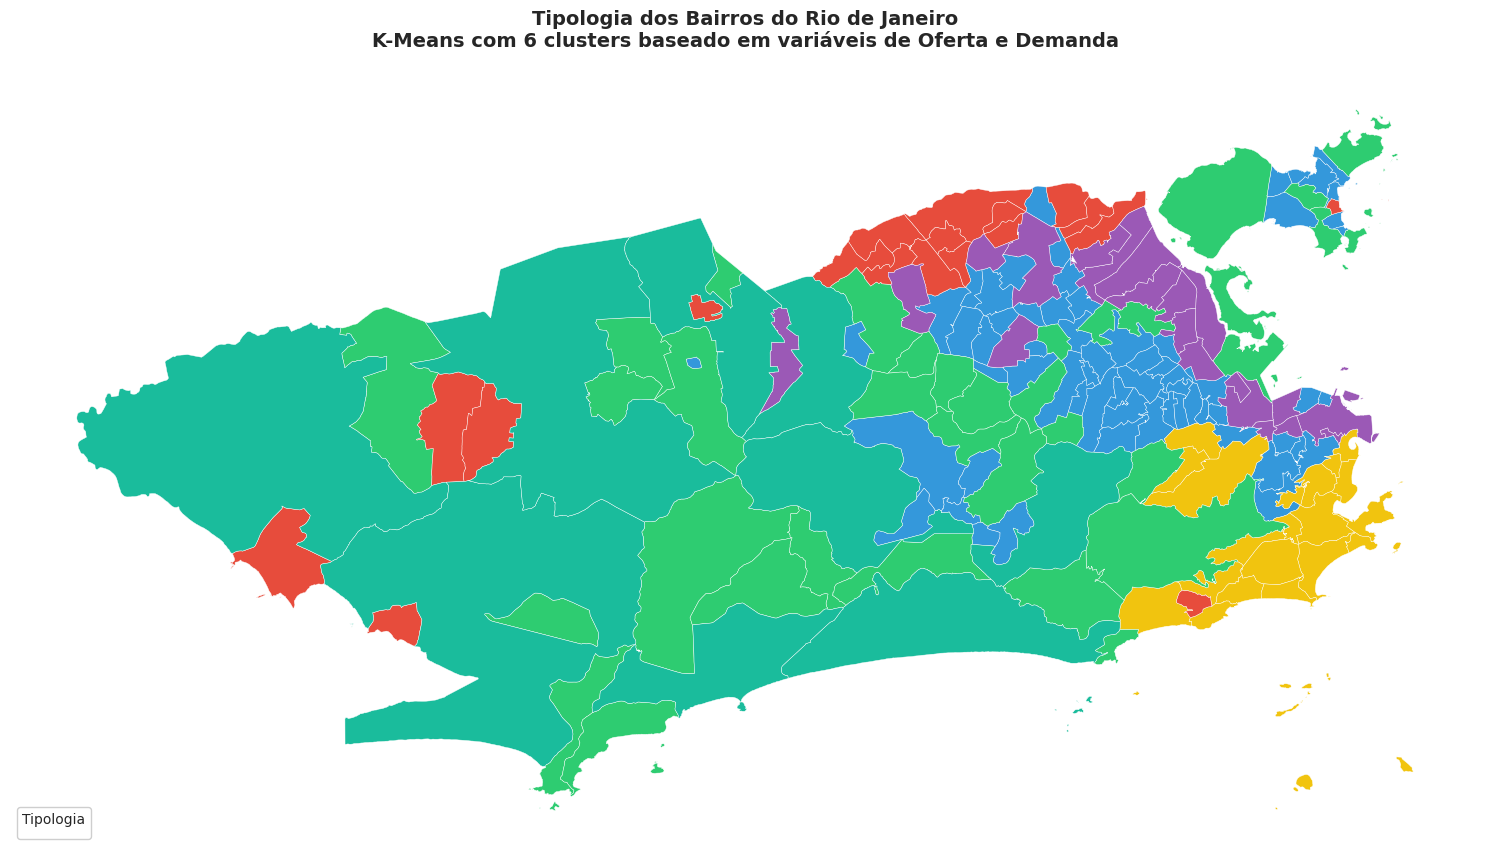

In [18]:
NOMES_CLUSTERS = {
    0: "Periferia Densa Urbana",
    1: "Bairros Privilegiados",
    2: "Periferia Territorial Vulnerável",
    3: "Desertos Sociais Críticos",
    4: "Hubs de Linhas Estratégicos",
    5: "Megabairros de Corredor",
}

df["nome_cluster"] = df["cluster"].map(NOMES_CLUSTERS)

fig, ax = plt.subplots(figsize=(15, 10))

# Cores semânticas
cores_clusters = {
    0: "#3498db",  # azul - periferia densa
    1: "#f1c40f",  # amarelo - privilegiados
    2: "#2ecc71",  # verde - periferia territorial
    3: "#e74c3c",  # vermelho - desertos sociais
    4: "#9b59b6",  # roxo - hubs
    5: "#1abc9c",  # ciano - megabairros
}

for cluster_id, nome in NOMES_CLUSTERS.items():
    df[df["cluster"] == cluster_id].plot(
        ax=ax,
        color=cores_clusters[cluster_id],
        edgecolor="white",
        linewidth=0.3,
        label=f"{cluster_id} - {nome} ({(df['cluster']==cluster_id).sum()} bairros)"
    )

ax.set_title(
    "Tipologia dos Bairros do Rio de Janeiro\n"
    "K-Means com 6 clusters baseado em variáveis de Oferta e Demanda",
    fontsize=14, fontweight='bold', pad=20
)
ax.set_axis_off()
ax.legend(loc='lower left', fontsize=10, framealpha=0.95, title="Tipologia")

plt.tight_layout()


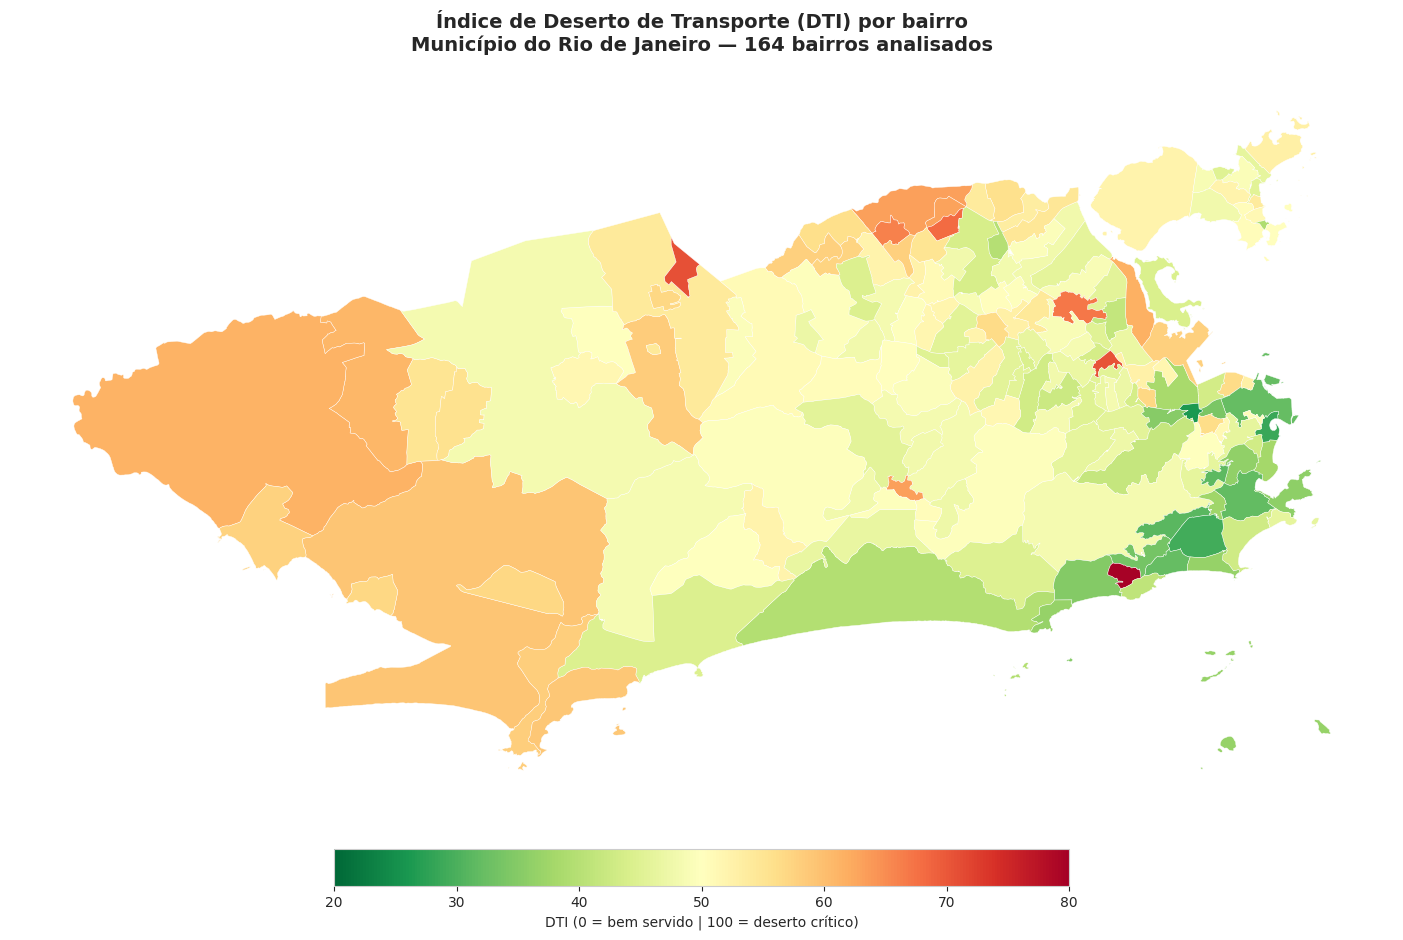

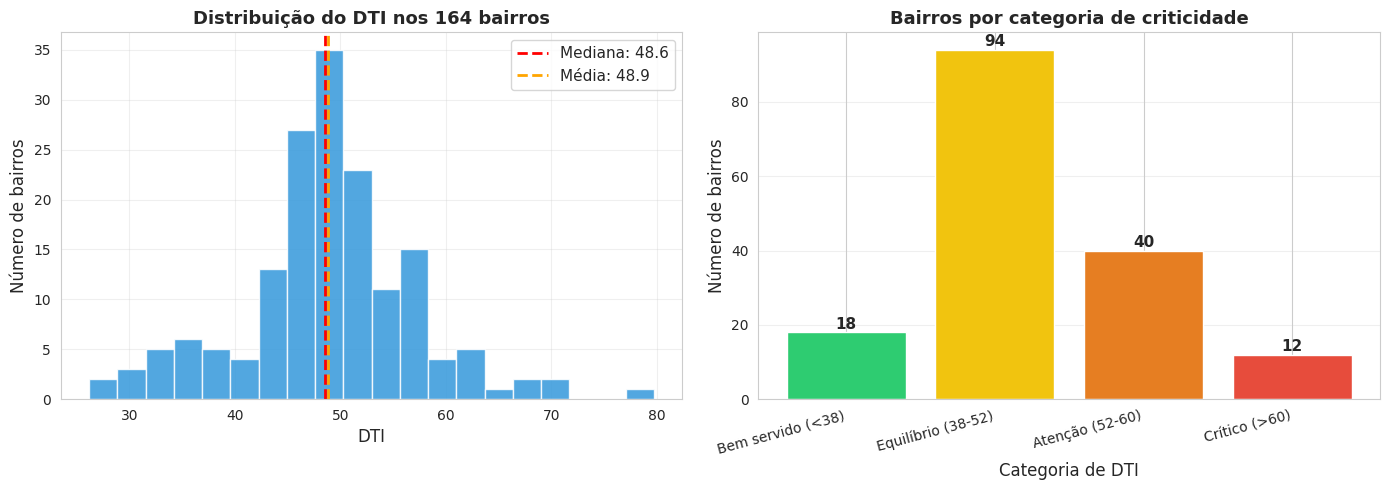

In [25]:
df = gpd.read_parquet("../data/processed/bairros_dti_clusters.parquet")
df = df.set_crs("EPSG:4326")

fig, ax = plt.subplots(figsize=(15, 10))

df.plot(
    column="DTI",
    cmap="RdYlGn_r",
    legend=True,
    edgecolor="white",
    linewidth=0.3,
    ax=ax,
    legend_kwds={
        "label": "DTI (0 = bem servido | 100 = deserto crítico)",
        "orientation": "horizontal",
        "shrink": 0.5,
        "pad": 0.05,
    },
    vmin=20,
    vmax=80,
)

ax.set_title(
    "Índice de Deserto de Transporte (DTI) por bairro\n"
    "Município do Rio de Janeiro — 164 bairros analisados",
    fontsize=14, fontweight='bold', pad=20
)
ax.set_axis_off()

plt.tight_layout()
# plt.savefig('reports/figures/01_mapa_dti.png', bbox_inches='tight', dpi=150)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df["DTI"], bins=20, color="#3498db", edgecolor="white", alpha=0.85)
axes[0].axvline(df["DTI"].median(), color="red", linestyle="--", linewidth=2, label=f"Mediana: {df['DTI'].median():.1f}")
axes[0].axvline(df["DTI"].mean(), color="orange", linestyle="--", linewidth=2, label=f"Média: {df['DTI'].mean():.1f}")
axes[0].set_xlabel("DTI", fontsize=12)
axes[0].set_ylabel("Número de bairros", fontsize=12)
axes[0].set_title("Distribuição do DTI nos 164 bairros", fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Boxplot por categoria
df["categoria"] = pd.cut(
    df["DTI"], 
    bins=[0, 38, 52, 60, 100],
    labels=["Bem servido (<38)", "Equilíbrio (38-52)", "Atenção (52-60)", "Crítico (>60)"]
)

cores_categoria = ["#2ecc71", "#f1c40f", "#e67e22", "#e74c3c"]
contagem = df["categoria"].value_counts().sort_index()

axes[1].bar(
    contagem.index, 
    contagem.values, 
    color=cores_categoria, 
    edgecolor="white"
)
axes[1].set_xlabel("Categoria de DTI", fontsize=12)
axes[1].set_ylabel("Número de bairros", fontsize=12)
axes[1].set_title("Bairros por categoria de criticidade", fontsize=13, fontweight='bold')

# Adicionar números no topo das barras
for i, v in enumerate(contagem.values):
    axes[1].text(i, v + 1, str(v), ha='center', fontweight='bold', fontsize=11)

plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=15, ha="right")
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
# plt.savefig('reports/figures/03_distribuicao_dti.png', bbox_inches='tight', dpi=150)
plt.show()